# Model Spikey observed by Plato(Sim) with UltraNest

In this notebook we use the Bayesian inference package `UltraNest`, using nested sampling, to model the Plato simulation of Spikey.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Built-in
import os
import sys
import json
import copy
import datetime

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path
from functools import partial
# UltraNest
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

# Internal methods
sys.path.append('../src')
import smbhb as smbhb
import bayes as bs
import utils as ut
import plots as pt
pt.setup()

In [3]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'
c = 'lightseagreen'

---
## 1. Model QDM Plato light curve with 1-d cadence
---

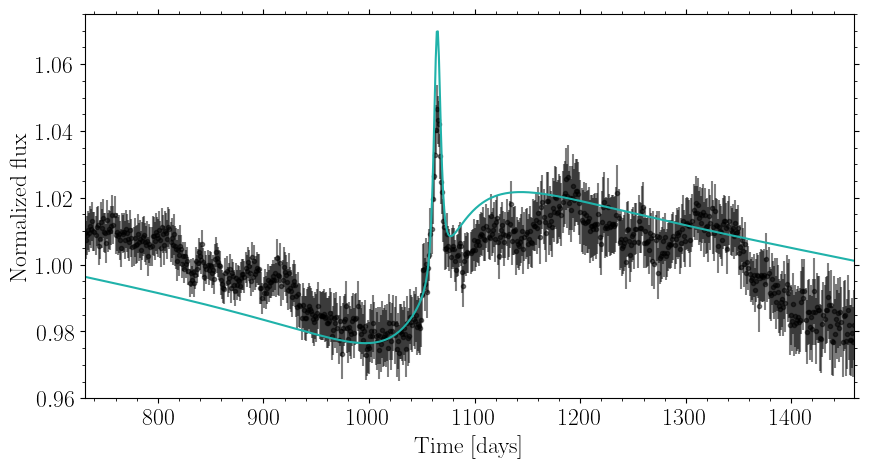

In [14]:
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_feather(ddir / 'lc_spikey_fiducial_1h.ftr')

# Bin light curve
df = ut.bin_lc(df, bin_size=1)
time = df.time.to_numpy()

# Generate relativistic Spikey model
params = smbhb.model_params()
params.t0    = 0.712
params.sigma = 0 
params.seed  = params.seed
model = smbhb.model(params)
dm = model.light_curve(time, df=True)

# Normalize light curve to model
df.flux = df.flux * dm.flux.median() / df.flux.median()

# Plot light curve
pt.plot_lc(df, dm, cm=c);

---
### 1.1. Parameterization with `logM1` and `logM2`

In [15]:
values = [params.t0, params.P, params.i, params.e, params.w, params.logM1, params.logM2, params.L, params.alpha]

#### *1.1.1. Uniform priors*

In [16]:
# Fast test with tight priors
filename = 'spikey_plato_DM_bin5d_logM1logM2_ultranest_uniform_test0'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05]
priors.P     = [params.P*0.95, params.P*1.05]
priors.i     = [0., 90.]
priors.e     = [params.e*0.9, params.e*1.1]
priors.w     = [params.w*0.9, params.w*1.1]
priors.logM1 = [5., 11.]
priors.logM2 = [5., 11.]
priors.L     = [0., 1.]
priors.alpha = [params.alpha*0.9, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+02  .16 [-344.5782..-344.5770]*| it/evals=12351/887847 eff=1.3917% N=400 =400     
# [ultranest] Likelihood function evaluations: 888210
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -370.6 +- 0.1687
# [ultranest] Effective samples strategy satisfied (ESS = 3590.3, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
# [ultranest]   logZ error budget: single: 0.23 bs:0.17 tail:0.01 total:0.17 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:01:59.724970 [h:mm:ss]

# logZ = -370.555 +- 0.316
#   single instance: logZ = -370.555 +- 0.232
#   bootstrapped   : logZ = -370.605 +- 0.316
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.96 (should be >1), far enough fraction: 51.11% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 0.676 │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▄▅▅▆▆▇│0.748     0.736 +- 0.011
#     P                   : 1.1162│ ▁▁▂▇▇▇▆▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ │1.1605    1.1267 +- 0.0057
#     i                   : 73.5  │ ▁  ▁ ▁▁▁▁▁▁▁▃▃▃▅▅▇▇▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │87.6      81.0 +- 1.5
#     e                   : 0.5106│ ▁    ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▅▆▆▇│0.5764    0.5674 +- 0.0083
#     w                   : 76.17 │▇▇▅▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁▁▁▁▁▁▁ │79.84     76.67 +- 0.46
#     logM1               : 6.51  │ ▁ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇▇▇▇▇▆▅▃▃▂▁▁▁▁▁ ▁ │8.09      7.43 +- 0.18
#     logM2               : 6.26  │ ▁▁  ▁ ▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇▇▇▇▆▅▃▂▁▁▁▁ ▁ │8.24      7.53 +- 0.21
#     L                   : 0.638 │ ▁ ▁▁▁▁▁▁▂▂▂▃▄▅▆▇▇▇▇▇▇▅▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁│1.000     0.816 +- 0.044
#     alpha               : 1.88  │▆▇▇▇▆▇▅▇▆▆▅▆▆▅▄▅▄▅▃▃▄▅▄▂▃▂▃▂▂▂▂▁▂▁▁▁▁▁▁│2.30      2.02 +- 0.10

In [22]:
# Try-and-error to get coherent distributions
filename = 'spikey_plato_DM_bin5d_logM1logM2_ultranest_uniform_test1'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.1]
priors.P     = [params.P*0.9, params.P*1.05]
priors.i     = [0, 90]
priors.e     = [params.e*0.9, params.e*1.5]
priors.w     = [params.w*0.5, params.w*1.1] # Changed
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.3, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+02  .36 [-338.3221..-338.3218]*| it/evals=11760/10552929 eff=0.1114% N=400 
# [ultranest] Likelihood function evaluations: 10553308
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -362.8 +- 0.2032
# [ultranest] Effective samples strategy satisfied (ESS = 3565.8, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.16 to 0.51, need <0.5)
# [ultranest]   logZ error budget: single: 0.23 bs:0.20 tail:0.01 total:0.20 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:21:40.371521 [h:mm:ss]

# logZ = -362.883 +- 0.398
#   single instance: logZ = -362.883 +- 0.226
#   bootstrapped   : logZ = -362.841 +- 0.398
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.89 (should be >1), far enough fraction: 42.54% : very fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 0.676 │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▅▅▇▇│0.783     0.764 +- 0.018
#     P                   : 1.064 │ ▁ ▁▁▁▁▂▂▂▁▁▁▂▄▇▇▇▆▄▃▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁ │1.163     1.109 +- 0.013
#     i                   : 70.0  │ ▁          ▁▁▁▁▁▁▁▁▃▄▅▆▇▇▇▇▅▄▂▂▁▁▁▁▁▁ │89.7      82.9 +- 1.6
#     e                   : 0.472 │▁▁▁▁▁▁▁▁▂▃▄▅▆▇▇▇▇▆▅▄▃▃▃▁▁▁▁▁▁▁▁▁▁ ▁▁  ▁│0.786     0.598 +- 0.034
#     w                   : 42.3  │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁    ▁▁▁▁▁▂▃▆▇▇▆▅▂▁▁▁▁ │83.9      70.5 +- 10.0
#     logM1               : 6.02  │ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▄▄▆▇▇▇▇▆▆▅▄▃▂▁▁▁▁▁▁ │7.94      7.19 +- 0.23
#     logM2               : 5.00  │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▄▆▇▇▇▇▅▄▂▁▁▁▁ │8.11      7.04 +- 0.64
#     L                   : 0.428 │ ▁▁▁▁▁▁▁▁▁▁▁▁▂▃▄▅▆▇▇▇▆▆▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁│1.000     0.736 +- 0.076
#     alpha               : 0.63  │▂▃▃▃▄▃▄▄▄▅▄▅▆▆▅▆▇▇▆▆▆▇▆▆▅▆▄▄▄▄▃▃▃▃▃▃▄▆▇│2.30      1.49 +- 0.43

In [18]:
# Proper modelling with wide priors
filename = 'spikey_plato_DM_bin5d_logM1logM2_ultranest_uniform'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [0.1, 3.]
priors.P     = [0.1, 3.]
priors.i     = [0.1, 89]
priors.e     = [0.1, 0.9]
priors.w     = [0.1, 359]
priors.logM1 = [5., 11.]
priors.logM2 = [5., 11.]
priors.L     = [0., 1.]
priors.alpha = [0.1, 4.]
priors.vz    = params.vz
# [ultranest] Explored until L=-1e+03  326.12 [-1327.0628..-1327.0623]*| it/evals=16503/71002412 eff=0.0232% N=400 
# [ultranest] Likelihood function evaluations: 71002412
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1364 +- 0.2399
# [ultranest] Effective samples strategy satisfied (ESS = 2974.7, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.20 to 0.52, need <0.5)
# [ultranest]   logZ error budget: single: 0.29 bs:0.24 tail:0.01 total:0.24 required:<0.50
# [ultranest] done iterating.
# Execution time: 5:33:25.395283 [h:mm:ss]

# logZ = -1363.500 +- 0.403
#   single instance: logZ = -1363.500 +- 0.288
#   bootstrapped   : logZ = -1363.537 +- 0.403
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.81 (should be >1), far enough fraction: 31.32% : very fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 0.10  │▃                ▁▇▁                ▃▁ │2.99      1.43 +- 0.87
#     P                   : 0.6919│ ▁ ▁▁▁▁▁▁▁▂▂▃▃▄▆▇▇▇▇▆▅▄▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁ │0.7300    0.7101 +- 0.0045
#     i                   : 80.03 │ ▁▁   ▁▁▁▁▁▁▁▁▂▂▂▃▄▅▆▇▇▇▇▇▆▅▄▂▂▁▁▁▁▁▁▁ │85.38     83.19 +- 0.56
#     e                   : 0.251 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▇▅▃▃▂▂▁▁▁▁▁▁▁▁ ▁ │0.380     0.315 +- 0.014
#     w                   : 31    │ ▁▃▇▁                             ▁▄▄▁ │245       127 +- 89
#     logM1               : 5.00  │▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁    ▁▁▂▄▇▇▅▃▁▁▁▁ │7.47      6.30 +- 0.79
#     logM2               : 5.00  │▃▃▃▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁     ▁▁▁▂▄▇▇▅▃▁▁▁ │7.39      6.11 +- 0.80
#     L                   : 0.00  │▆▃▂▁▁▁▁▁▁                      ▁▁▁▁▁▃▅▇│1.00      0.56 +- 0.46
#     alpha               : 1.909 │ ▁ ▁  ▁▁▁▁▁▁▁▁▁▁▁▂▃▃▄▅▆▆▆▇▆▅▄▃▂▁▁▁▁▁ ▁ │2.487     2.265 +- 0.056

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1e+03  326.12 [-1327.0628..-1327.0623]*| it/evals=16503/71002412 eff=0.0232% N=400 
[ultranest] Likelihood function evaluations: 71002412
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -1364 +- 0.2399
[ultranest] Effective samples strategy satisfied (ESS = 2974.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.20 to 0.52, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.24 tail:0.01 total:0.24 required:<0.50
[ultranest] done iterating.
Execution time: 5:33:25.395283 [h:mm:ss]

logZ = -1363.500 +- 0.403
  single instance: logZ = -1363.500 +- 0.288
  bootstrapped   : logZ = -1363.537 +- 0.403
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump di

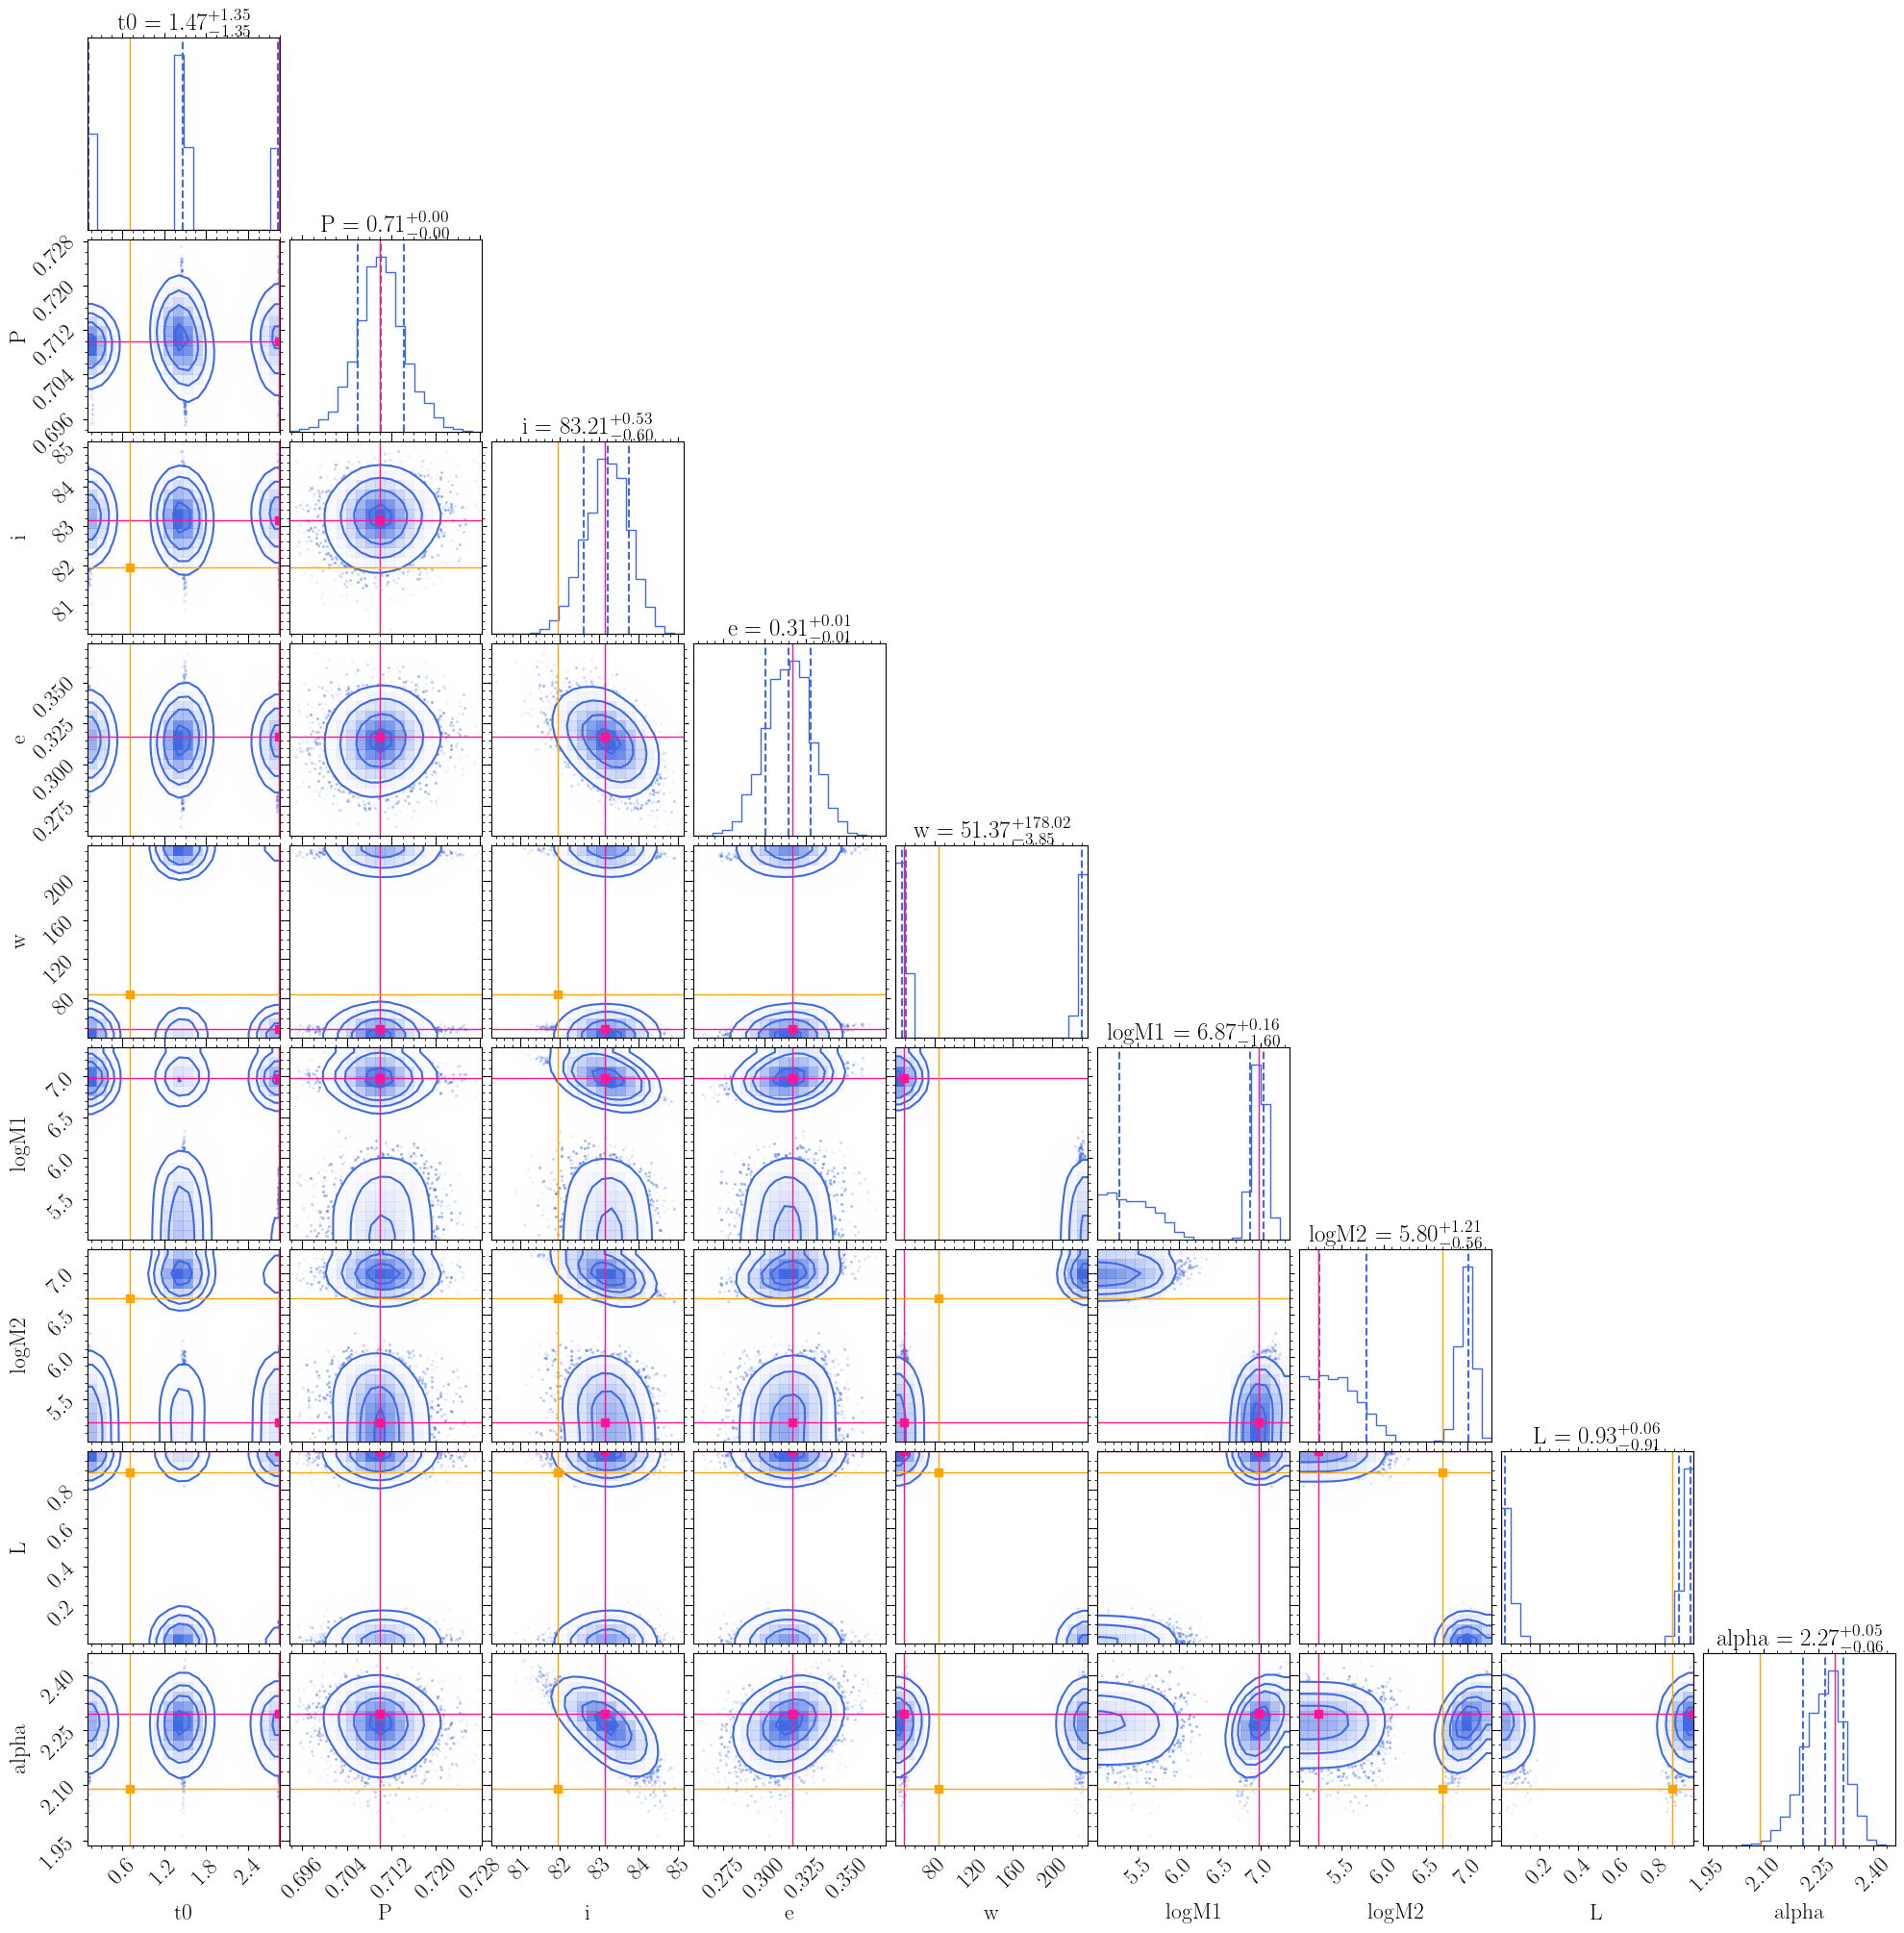

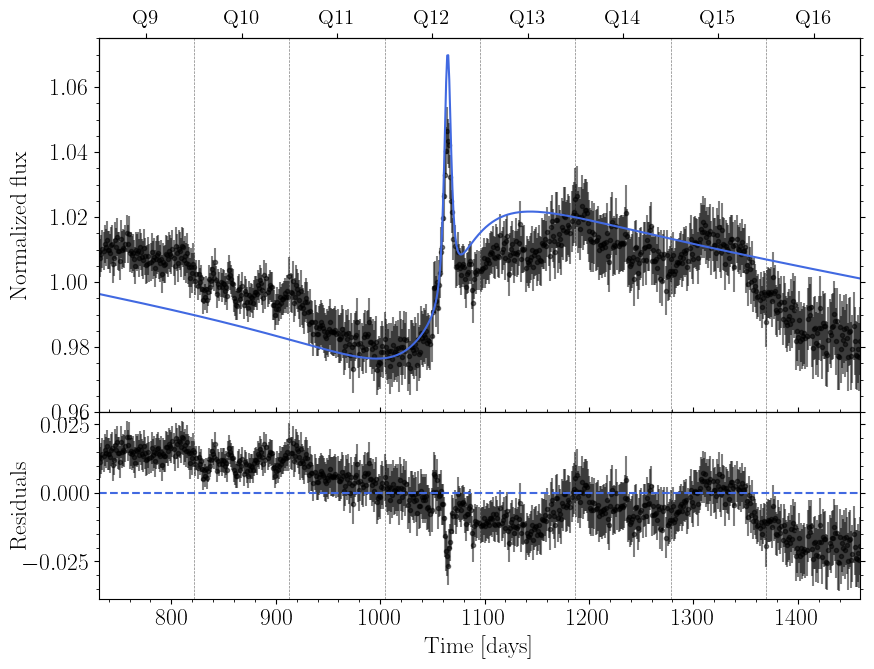

In [19]:
%%time
# Run UltraNest analysis
result, sampler = bs.run_ultranest(df, params, priors, rdir/filename)
# Show corner plot
fig = pt.plot_corner(result, bestfit='maximum', values_input=values);
fig.savefig(rdir / filename / 'plots' / f'{filename}_corner.png', bbox_inches='tight', dpi=200)
# Create best-fit model and plot along with data
params_model = copy.deepcopy(params)
params_model.sigma = 0
dm = bs.bestfit_model(time, params_model, result)
fig, ax = pt.plot_result(df, dm, alpha=0.5, Q0=1);
fig.savefig(rdir / filename / 'plots' / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

---
### 1.2. Paramterisation using `logM` and `q`

In [130]:
# Generate relativistic Spikey model
params = smbhb.model_params_q()
params.sigma = 0 
params.seed  = 12345
model = smbhb.model_q(params)
dm = model.light_curve(time, df=True)
params_input = [params.t0, params.P, params.i, params.e, params.w, params.logM, params.q, params.L, params.alpha]

#### *1.1.1. Uniform priors*

In [132]:
filename = 'spikey_kepler_DM_hu2020_ultranest_logMq_uniform'
priors = bs.model_priors_q()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05]
priors.P     = [params.P*0.95, params.P*1.05]
priors.i     = [0, 90]
priors.e     = [params.e*0.9, params.e*1.1]
priors.w     = [params.w*0.9, params.w*1.1]
priors.logM  = [5, 11]
priors.q     = [0, 1]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.9, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-4e+03  782.52 [-3783.3961..-3783.3957]*| it/evals=15225/668871 eff=2.2776% N=400    
# [ultranest] Likelihood function evaluations: 668890
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3817 +- 0.1918
# [ultranest] Effective samples strategy satisfied (ESS = 3233.2, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.19, need <0.5)
# [ultranest]   logZ error budget: single: 0.27 bs:0.19 tail:0.01 total:0.19 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:01:24.135220 [h:mm:ss]

# logZ = -3816.629 +- 0.488
#   single instance: logZ = -3816.629 +- 0.271
#   bootstrapped   : logZ = -3816.633 +- 0.488
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.94 (should be >1), far enough fraction: 50.92% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.06344│ ▁ ▁▁▁▁▁▁▁▁▂▂▄▄▅▆▆▇▇▇▆▆▅▄▃▃▂▁▁▁▁▁▁▁ ▁▁ │1.06568    1.06455 +- 0.00027
#     P                   : 1.1176│ ▁▁▁▁▁▁▁▁▁▂▂▄▅▅▆▆▇▇▇▇▅▅▄▄▃▂▁▁▁▁▁▁▁▁▁ ▁ │1.2012    1.1571 +- 0.0100
#     i                   : 81.54 │ ▁ ▁▁▁▁▁▁▁▂▂▂▄▄▅▆▆▇▇▇▇▇▅▅▃▃▂▁▁▁▁▁▁▁  ▁ │83.93     82.73 +- 0.28
#     e                   : 0.472 │▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▇▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁   ▁ │0.554     0.503 +- 0.011
#     w                   : 92.630│ ▁  ▁   ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▅▆▇│93.093    93.045 +- 0.048
#     logM                : 7.203 │ ▁ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▅▆▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁ │7.682     7.472 +- 0.056
#     q                   : 0.154 │ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▅▆▇▇▆▆▆▄▃▃▂▁▁▁▁▁▁▁ ▁ │0.875     0.537 +- 0.087
#     L                   : 0.9406│ ▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▃▃▃▄▄▄▅▇▇▇▇│1.0000    0.9904 +- 0.0081
#     alpha               : 1.881 │▁▂▂▂▃▃▄▅▅▆▆▇▇▆▇▇▆▆▄▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁ ▁ │2.166     1.979 +- 0.042

In [134]:
filename = 'spikey_kepler_hu2020_uniform_test1'
priors = bs.model_priors_q()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.1]
priors.P     = [params.P*0.9, params.P*1.3]
priors.i     = [0, 90]
priors.e     = [params.e*0.5, params.e*1.5]
priors.w     = [params.w*0.5, params.w*2.5]
priors.logM  = [5, 11]
priors.q     = [0, 1]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.5, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+03  365.72 [-3366.5589..-3366.5586]*| it/evals=16840/1621327 eff=1.0389% N=400  
# [ultranest] Likelihood function evaluations: 1621668
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3404 +- 0.243
# [ultranest] Effective samples strategy satisfied (ESS = 3311.1, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.20 to 0.53, need <0.5)
# [ultranest]   logZ error budget: single: 0.29 bs:0.24 tail:0.01 total:0.24 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:02:51.740354 [h:mm:ss]

# logZ = -3403.857 +- 0.412
#   single instance: logZ = -3403.857 +- 0.289
#   bootstrapped   : logZ = -3403.891 +- 0.412
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.76% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.0987│ ▁▁▁▁▁▁▁▁▂▃▄▅▇▇▇▇▆▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁ ▁▁ │1.1211    1.1081 +- 0.0024
#     P                   : 1.197 │ ▁▁▁▁▁▁▁▁▁▁▂▃▄▅▆▆▆▇▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁  ▁ │1.386     1.284 +- 0.020
#     i                   : 80.37 │ ▁   ▁▁▁▁▁▁▁▁▂▂▃▄▅▇▇▇▇▇▆▆▄▄▂▂▁▁▁▁▁▁▁▁▁ │83.34     81.97 +- 0.30
#     e                   : 0.5888│ ▁▁▁▁▁▁▁▁▁▂▂▃▃▅▅▇▇▇▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.6530    0.6209 +- 0.0081
#     w                   : 121.8 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▅▄▆▆▇▇▇▇▅▅▄▃▃▂▁▁▁▁▁▁▁▁ ▁ │132.0     126.9 +- 1.2
#     logM                : 7.493 │ ▁   ▁ ▁▁▁▁▁▁▁▂▃▄▆▆▇▇▇▆▅▄▃▂▂▁▁▁▁▁  ▁▁▁ │7.882     7.697 +- 0.037
#     q                   : 0.857 │ ▁ ▁▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▇▇│1.000     0.985 +- 0.015
#     L                   : 0.796 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▄▅▇▇▇▇▇▆▅▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.933     0.866 +- 0.016
#     alpha               : 1.100 │ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▇▆▄▃▂▁▁▁▁▁▁▁  ▁ │1.834     1.484 +- 0.083

In [17]:
filename = 'spikey_kepler_hu2020_uniform_test2'
priors = bs.model_priors_q()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.1]
priors.P     = [params.P*0.9, params.P*1.3]
priors.i     = [0, 90]
priors.e     = [0.1, 0.9]
priors.w     = [0, 360]
priors.logM  = [5, 11]
priors.q     = [0, 1]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.5, params.alpha*1.1]
priors.vz    = params.vz

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+03  389.87 [-3390.8275..-3390.8274]*| it/evals=16360/1533330 eff=1.0672% N=400 00   
[ultranest] Likelihood function evaluations: 1533560
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -3427 +- 0.1772
[ultranest] Effective samples strategy satisfied (ESS = 3143.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.
Execution time: 0:02:57.235538 [h:mm:ss]

logZ = -3426.908 +- 0.329
  single instance: logZ = -3426.908 +- 0.284
  bootstrapped   : logZ = -3426.899 +- 0.329
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 0.95 (should be >1),

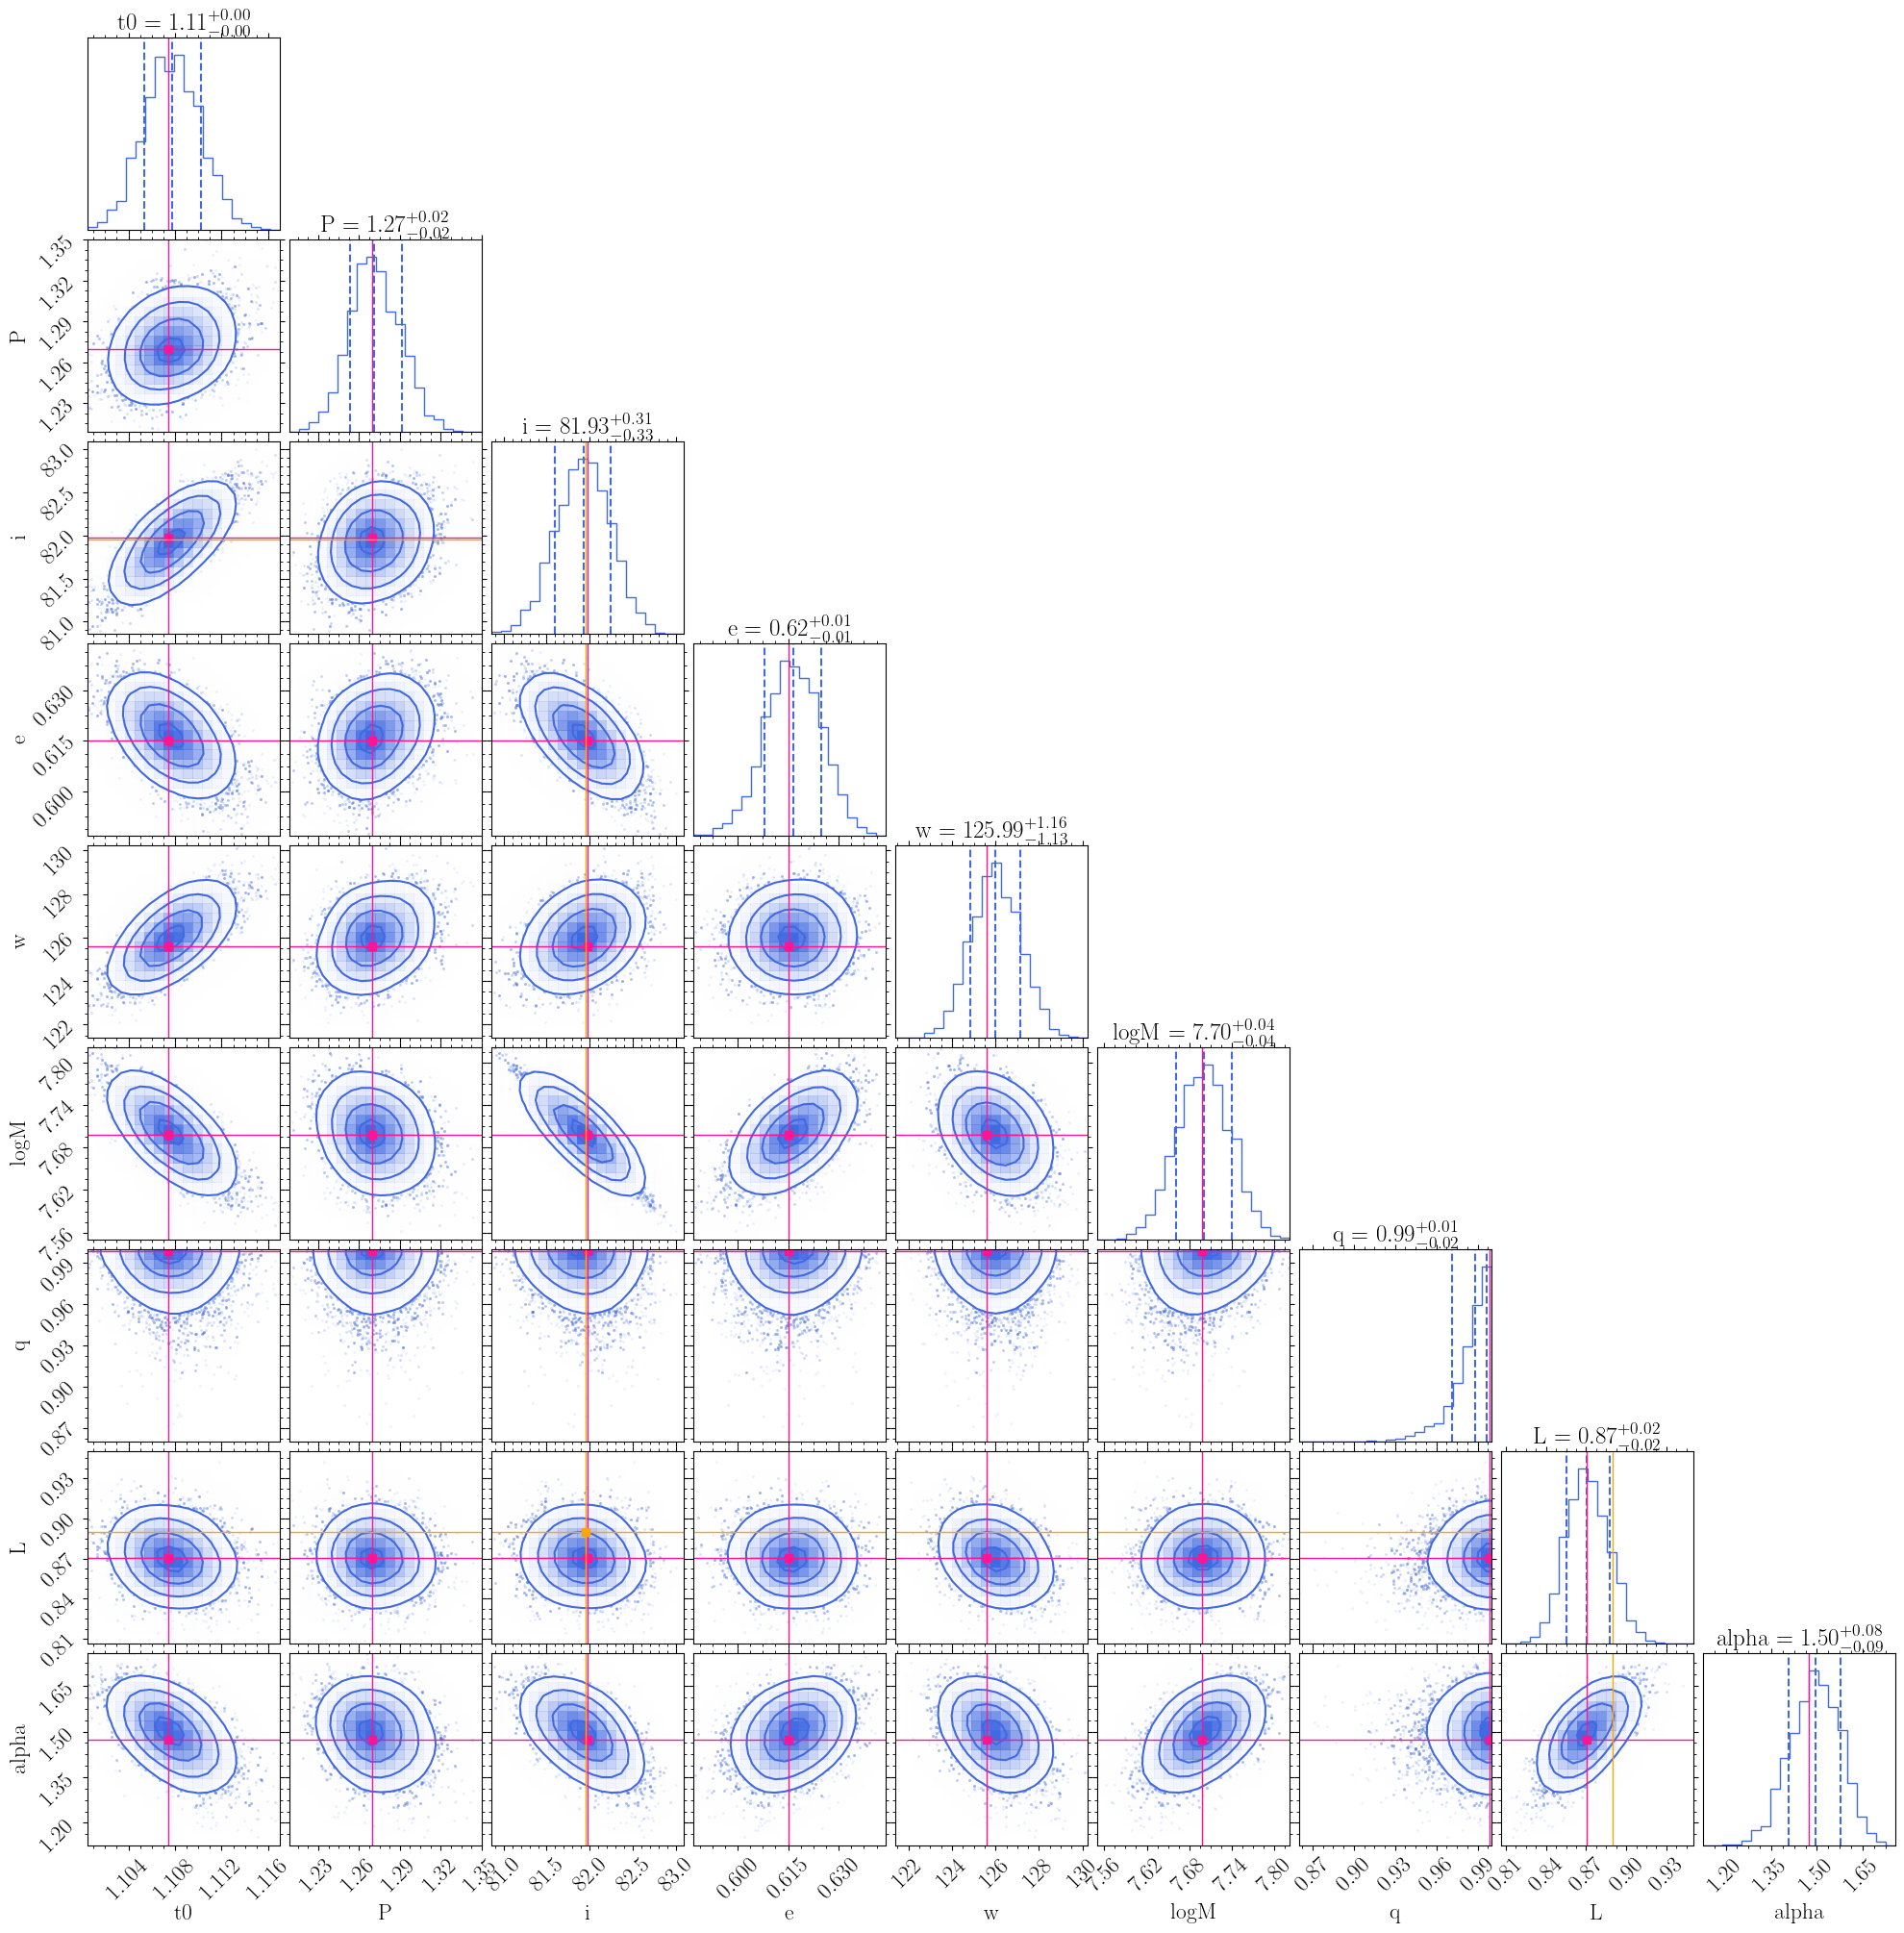

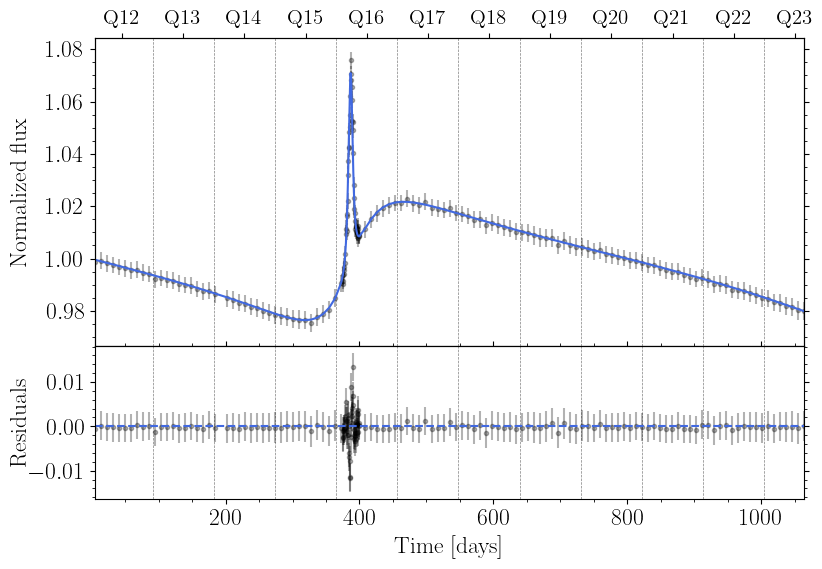

In [135]:
# Run UltraNest analysis
result, sampler = bs.run_ultranest_q(df, params, priors, rdir/filename)
# Show corner plot
fig = pt.plot_corner(result, bestfit='maximum', values_input=params_input);
fig.savefig(fdir / f'{filename}_cornerplot.png', bbox_inches='tight', dpi=200)
# Create best-fit model and plot along with data
params_model = copy.deepcopy(params)
params_model.sigma = 0
dm = bs.bestfit_model_q(time, params_model, result)
fig, ax = pt.plot_result(df, dm, Q0=9, alpha=0.3, figsize=(8.5, 6));
fig.savefig(fdir / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)